**Laboratory 2: Wednesday 08/04/2025**

In [1]:
!pip install pennylane

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 7.8 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 12.4 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.5 MB/s eta 0:00:0031m10.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 7.4 MB/s eta 0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 13.4 MB/s eta 0:00:00m eta 0:00:010:00:01


In [2]:
# basic imports

import pennylane as qml
from pennylane import numpy as np # always import numpy like this!

/home/timofey/envTF/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


# **Differentiable quantum circuits on Pennylane**

In the last lecture, we promised that:

Unlike other quantum programming libraries, Pennylane is based on the following feature

*   **Follow the gradient.** Built-in **automatic differentiation** of quantum circuits.


For a quick recap of what automatic differentiation is, check it here: [link](https://pennylane.ai/qml/glossary/quantum_differentiable_programming/). This provides a very clear explanation (recommended!)

<p align="center">
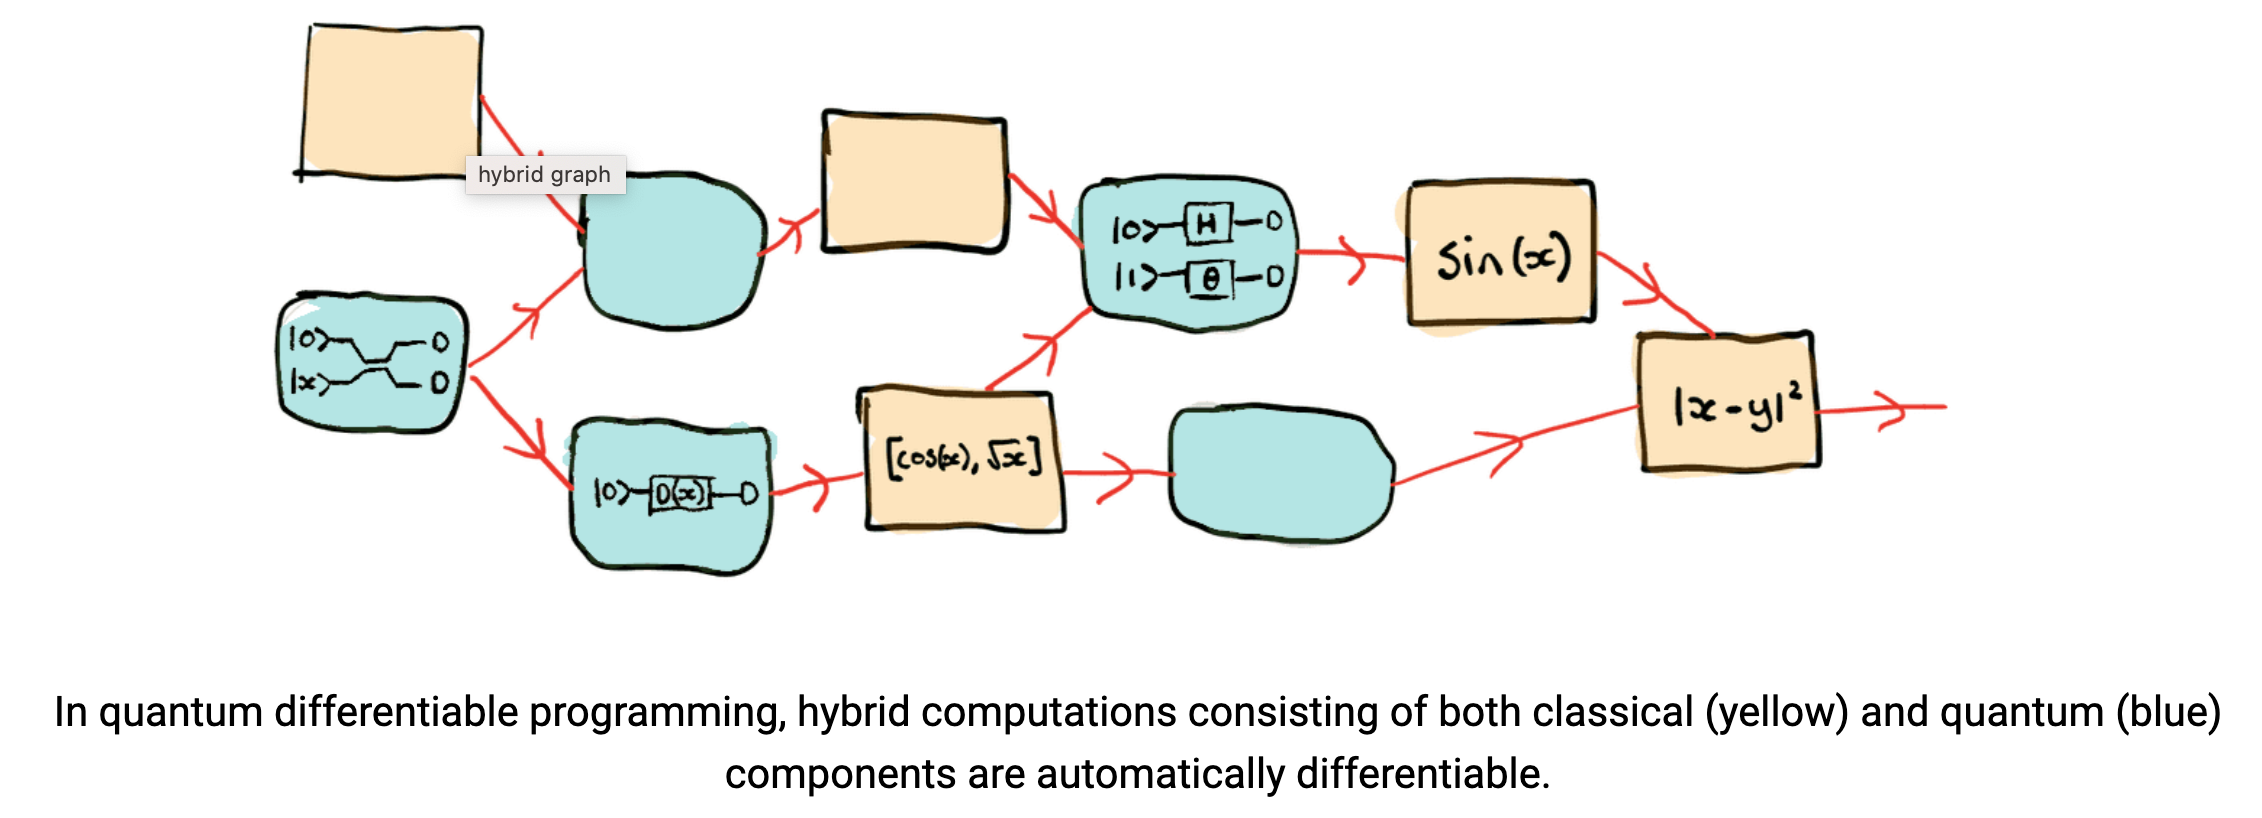
</p>


In this second hands-on tutorial, we will show how to create a Parameterized Quantum Circuit (PQC) and to compute gradients of a cost function w.r.t. its parameters.
This way, we can optimize the PQC by *minimizing a cost function with gradient-based methods* (examples below).

**In other words, by computing gradients, we can make quantum algorithms trainable**.

Derivatives of a PQC are computed thanks to an **interface**, which can be: autograd ([automatically differentiate native Python and Numpy code](https://github.com/HIPS/autograd)), TensorFlow, PyTorch, or JAX.

> Interfaces: different Automatic Differentiation (AD) frameworks

Example: `interface="autograd"`

In PennyLane, any quantum **device**, whether a classical simulator or a real quantum-hardware-device, can be trained.

Example (basic simulator): `dev = qml.device("default.qubit", wires=2)`


### Recall that:

The fundamental element introduced in pennylane is the quantum node (`qnode`) which allows you to interface the quantum circuit with a device (either a real quantum device or a classical simulator, as in this case).

A `qnode`  is applied as a decorator to a **quantum function** that defines the quantum circuit: the function becomes itself an object of the class `QNode`.

What is a **quantum function**?

Quantum functions are a **restricted subset** of Python functions.
For a Python function to also be a valid quantum function, there are some
important restrictions:

* **Quantum functions must contain quantum operations, one operation per line,
in the order in which they are to be applied.**

* In addition, we must always specify the subsystem the operation applies to,
 by passing the ``wires`` argument; this may be a list or an integer, depending
on how many wires the operation acts on.

* **Quantum functions must return either a single or a tuple of measured observables**.
As a result, the quantum function always returns a classical quantity


### My first simple example of PQC

In [ ]:
# create a device to execute the circuit on: a classical simulator with 2 qubits
dev = qml.device("default.qubit", wires=2)

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

@qml.qnode(dev, interface="autograd")
def circuit(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)

In [ ]:
# set the random seed for reproducibility
np.random.seed(42)

# two random rotation angles
params_values = np.random.random([2], requires_grad=True) # you will compute gradients wrt to these parameters

fig, ax = qml.draw_mpl(circuit, decimals=2)(params_values)
fig.show()

> The gradient of the function circuit, encapsulated within the QNode, can be evaluated by utilizing the same quantum device `dev`
>that we used to evaluate the function itself.

PennyLane incorporates both **analytic** differentiation, as well as **numerical** methods (such as the method of *finite differences*). Both of these are done automatically.

We can differentiate by using the built-in `grad()` function.

> NB: `grad()` is intended to be used with the Autograd interface only
>
> To see how to use other interfaces, e.g. PyTorch, check this link: [Gradients and training](https://docs.pennylane.ai/en/stable/introduction/interfaces.html).

**This returns another function, representing the gradient (i.e., the vector of partial derivatives) of circuit.**

The gradient can be evaluated in the same way as the original function:

In [ ]:
dcircuit = qml.grad(circuit, argnum=0) # there is a single argument, which is params (a list of size 2)

# NB:
# if you passed two variables separately as in
# circuit(param0, param1)
# you would use argnum=0 and argnum=1 (respectively) for the two partial derivatives

In [ ]:
# evaluate at params = params_values
print("Parameters:", params_values)
print("Expectation value:", circuit(params_values))
print("Gradient:", dcircuit(params_values))

**Remark**:
Keyword arguments (**kwargs) may also be used in your custom quantum function.

>PennyLane does **not** differentiate QNodes with respect to keyword arguments, so they are useful for passing external data to your QNode.

### A moment of reflection

What does it mean to compute the gradient of `circuit`?

It is an **abuse of notation**. We are computing the gradient of a **quantum function** named circuit. This function returns the expectation value of $$Z \otimes Z$$ in the Parameterized Quantum Circuit above, let us call it

$$
| \psi(\theta_0, \theta_1)\rangle = e^{-i \frac{\theta_0}{2}X_0  } e^{-i \frac{\theta_1}{2}Y_1  } C_{0,1} H_0 |00\rangle
$$


So, we are actually computing the **gradient of the cost function** (expectation value):

$$
\mathrm{C}(\theta_0, \theta_1) = \langle \psi  (\theta_0, \theta_1) | Z_0 \otimes Z_1 | \psi (\theta_0, \theta_1) \rangle
$$

> Pro tip: exercise to try at home. Compute analytically (pen and paper) this gradient. Do you see the imaginary part of an expectation value appearing?

> We can rewrite $|00\rangle \equiv |0\rangle^{\otimes N}$, here with $N=2$ qubits

---

## Different methods to compute gradients with Pennylane

We just used `grad()`... But what method did we actually use to compute the gradient of $\mathrm{C}(\theta_0, \theta_1)$?

>Pennylane chooses the "best" option (analytical gradients, if possible). But it is extremely important to understand the different
>
>methods that we can use to differentiate a quantum circuit (or, more precisely, to compute the partial derivative of the cost function):
>
>in our case $\mathrm{C}(\theta_0, \theta_1)$).

In particular, you **should** understand very well:
1. What methods can **only** be used in a classical simulation with the exact `statevetor` (wavefunction)

2. What methods can be used also in a real experiment on a quantum device, with `shots`

### 1. Simulation-based differentiation

These methods are essentially the standard **backpropagation**, which is used everywhere in classical Machine Learning (e.g. for feed-forward Neural Networks like multilayer perceptrons).

They are based on the chain rule, and compute gradients of $\mathrm{C}(\theta_0, \theta_1)$ recursively starting from the final layer: they use [**reverse accumulation** AD](https://en.wikipedia.org/wiki/Automatic_differentiation).

* "backprop": Use standard backpropagation

* "adjoint": Use a form of backpropagation that takes advantage of the unitary or reversible nature of quantum computation. Lower memory usage and a similar runtime compared to backprop

> In a **real device** (with e.g. $N \sim 100$ qubits) we CANNOT compute the final quantum state (here, $| \psi (\theta_0, \theta_1) \rangle$) exactly. Hence, we do not have the exact cost function (here, $\mathrm{C}(\theta_0, \theta_1)$).
>
> On the contrary for **fixed variational parameters** (here, $(\theta_0, \theta_1)$), we estimate it with a bunch of measurements, or **shots**, on the final state: see the last lecture.
>
> As a consequence, we CANNOT compute the partial derivates with backpropagation!

### 2. Hardware-compatible differentiation

These methods support **both quantum hardware and simulators**. They are examples of forward accumulation AD.

> However, when using a simulator, notice that the number of circuit executions required to compute the gradients with these methods scales **linearly with the number of trainable circuit parameters**! Backprop is often more efficient.

Most important methods (see the same link above for a complete list [Gradients and training](https://docs.pennylane.ai/en/stable/introduction/interfaces.html)):

* "finite-diff": Use numerical finite-differences for all quantum operation arguments. Numerical approximation, risk of high numerical errors

* "parameter-shift": Use the analytic **parameter-shift rule** for all supported quantum operation arguments, with finite-difference as a fallback.

## Parameter shift rule (PSR)

Let us start with the intuition behind PSR. Consider $f(x) = \sin(x)$.

- **Finite differences** (second order in $\epsilon$):
$$
\frac{d(\sin(x))}{dx} \approx \frac{\sin(x + \epsilon) - \sin(x - \epsilon)}{2\epsilon}
$$

- **Exact** (for any real $s$):
$$
\frac{d(\sin(x))}{dx} = \cos(x) = \frac{\sin(x + s) - \sin(x - s)}{2\sin(s)}
$$

> Note that $\epsilon$ is small. Numerical errors. If you have noise, it fails completely.
>
> Note that $s$ is finite! E.g. choose $s=\frac{\pi}{2}$. Much better resilience to numerical errors and noise.


This  approach can be extended to quantum gates and Parameterized Quantum Circuits.

Indeed, the **PSR is ideally suited to hardware devices**, as it answers to the question:

> how do I compute gradients of a PQC implemented on a real quantum device?

### Simple PSR

Generalized versions exist (advanced topic, you can Google it if interested).


Here,  we focus on a variational quantum circuit $U(\boldsymbol{θ}) = (\theta_1, \theta_2, \dots, \theta_M)$ acting on $N$ qubits, which is composed of non-parametrical gates (e.g. CNOTs, Hadamard) and $M$
parameterized Pauli rotations (see e.g. $| \psi(\theta_0, \theta_1)\rangle$ above):
$$
 R_\alpha(\theta_j) = e^{-i \frac{\theta_j}{2}\sigma_\alpha} = \mathrm{I}\cos{\frac{\theta_j}{2}} - i \sin{\frac{\theta_j}{2}} \sigma_\alpha \qquad \text{for} \ \ \alpha=x,y,z
$$
(as usual $\sigma_x \equiv X$ etc. is a Pauli matrix acting on some qubit - not specified here).


Let us consider some observable $B$, e.g. $Z_0 \otimes Z_1$ above (it can be any Hermitian operator!).

The cost function is the expectation value:

$\langle B (\boldsymbol{θ}) \rangle = \langle 0 |^{\otimes N} U^{†}(\boldsymbol{θ})\, B \ U(\boldsymbol{θ}) |0\rangle^{\otimes N}$

Its partial derivative with respect to the parameter $\theta_j$ is given by
$$
\frac{\partial}{\partial \theta_j} \langle B (\boldsymbol{θ}) \rangle =
\frac{1}{2} \left[ \langle {B} \left( \boldsymbol{θ} + \frac{\pi}{2} \hat{\boldsymbol{e}}_j \right) \rangle  - \langle {B} \left( \boldsymbol{θ} - \frac{\pi}{2} \hat{\boldsymbol{e}}_j \right) \rangle  \right].
$$
with $\hat{\boldsymbol{e}}_j$ being the versor along the $j$-th direction.

Thus, the gradient of the expectation value can be calculated by evaluating the **same variational quantum circuit**, but with **shifted parameter values** (hence the name, parameter-shift rule!)

For **each parameter** it is therefore necessary to estimate two expectation values using $K$ samples (or shots) taken from the quantum device (or simulator). The total number of calls to the quantum hardware for the case above, with two parameters, and 100 samples, would be 400.

In [3]:
np.random.seed(42)

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

# create a device to execute the circuit on: a classical simulator with 2 qubits and shots simulation
dev = qml.device("default.qubit", wires=2, shots=100)
# shots: number of samples (measurements)

@qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
def circuit(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)


params_values = np.random.random([2], requires_grad=True)

# evaluate at params = params_values
print("Parameters:", params_values)
print(f"Expectation value: {circuit(params_values):.4f}")

# gradient with PSR
dcircuit = qml.grad(circuit, argnum=0)
print(f"Gradient: {dcircuit(params_values)}")

Parameters: [0.18343479 0.779691  ]
Expectation value: 0.6400
Gradient: [-0.25 -0.62]


/home/timofey/envTF/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/home/timofey/envTF/lib/python3.12/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


Let's check with backpropagation

In [4]:
np.random.seed(42)

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

# create a device to execute the circuit on: a classical simulator with 2 qubits and shots simulation
dev = qml.device("default.qubit", wires=2)
# shots: number of samples (measurements)

@qml.qnode(dev, interface="autograd", diff_method="backprop")
def circuit(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)


params_values = np.random.random([2], requires_grad=True)

# evaluate at params = params_values
print("Parameters:", params_values)
print(f"Expectation value: {circuit(params_values):.4f}")

# gradient with backpropagation
dcircuit = qml.grad(circuit, argnum=0)
print(f"Gradient: {dcircuit(params_values)}")

Parameters: [0.18343479 0.779691  ]
Expectation value: 0.6992
Gradient: [-0.12971581 -0.69126445]


The results are fairly close! Of course, using more shots will bring PSR's gradient closer to the one computed by backpropagation (give it a try if ypu want!)


---
## Exercise 1

Redo the exact same thing with finite differences. Copy and paste.

Compare the exact case above, with PSR and with finite differences.
Which one is more accurate?
Why?

What happens with, say, $K=1000$ shots?


In [8]:
### copy and paste the cell above, change diff_method
np.random.seed(42)

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

# create a device to execute the circuit on: a classical simulator with 2 qubits and shots simulation
dev = qml.device("default.qubit", wires=2, shots=1000)
# shots: number of samples (measurements)

@qml.qnode(dev, interface="autograd", diff_method="finite-diff")
def circuit(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)


params_values = np.random.random([2], requires_grad=True)

# evaluate at params = params_values
print("Parameters:", params_values)
print(f"Expectation value: {circuit(params_values):.4f}")

# gradient with PSR
dcircuit = qml.grad(circuit, argnum=0)
print(f"Gradient: {dcircuit(params_values)}")

Parameters: [0.18343479 0.779691  ]
Expectation value: 0.6700
Gradient: [-340000. -360000.]


In [9]:
np.random.seed(42)

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

# create a device to execute the circuit on: a classical simulator with 2 qubits and shots simulation
dev = qml.device("default.qubit", wires=2)
# shots: number of samples (measurements)

@qml.qnode(dev, interface="autograd", diff_method="backprop")
def circuit(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)


params_values = np.random.random([2], requires_grad=True)

# evaluate at params = params_values
print("Parameters:", params_values)
print(f"Expectation value: {circuit(params_values):.4f}")

# gradient with backpropagation
dcircuit = qml.grad(circuit, argnum=0)
print(f"Gradient: {dcircuit(params_values)}")

Parameters: [0.18343479 0.779691  ]
Expectation value: 0.6992
Gradient: [-0.12971581 -0.69126445]


---

## Exercise 2

One of the previous methods failed. What would you do to make it work at least reasonably?

Check the documentation here: [link](https://docs.pennylane.ai/en/stable/code/api/pennylane.gradients.finite_diff.html)

What parameters would you change? Recall that the statistical error on the sample mean scales as

$$\sim\frac{1}{\sqrt{K}}$$

Hint:  You need MANY shots. Try `int(1e6) = 1000000` (ridicolous)...

Hint: you just need to modify one line, for instance as

`@qml.qnode(dev, interface="autograd", diff_method="finite-diff", gradient_kwargs ={"h": ..., "approx_order": ..., "strategy": ...})`



In [38]:
### copy and paste the cell above, change arguments of Qnode

np.random.seed(42)

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

# create a device to execute the circuit on: a classical simulator with 2 qubits and shots simulation
dev = qml.device("default.qubit", wires=2, shots=1000)
# shots: number of samples (measurements)

@qml.qnode(dev, interface="autograd", diff_method="finite-diff", gradient_kwargs={"h" : 1,"strategy": "center", "approx_order": 4})
def circuit(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)


params_values = np.random.random([2], requires_grad=True)

# evaluate at params = params_values
print("Parameters:", params_values)
print(f"Expectation value: {circuit(params_values):.4f}")

# gradient with PSR
dcircuit = qml.grad(circuit, argnum=0)
print(f"Gradient: {dcircuit(params_values)}")

Parameters: [0.18343479 0.779691  ]
Expectation value: 0.6700
Gradient: [-0.13883333 -0.71766667]


---

## Optimization of a Parameterized Quantum Circuit

We learnt how to differentiate PQCs to be able to train variational quantum algorithms.

Now, let us use PennyLane’s built-in optimizers to actually optimize the parameters of the circuit.

In our case, the observable is  $Z_0 \otimes Z_1$.
We optimize the variational parameters $(\theta_0, \theta_1)$ so as to minimize the cost function
$$
\mathrm{C}(\theta_0, \theta_1) = \langle \psi  (\theta_0, \theta_1) | Z_0 \otimes Z_1 | \psi (\theta_0, \theta_1) \rangle
$$

In [39]:
np.random.seed(42)
dev = qml.device("default.qubit", wires=2) # exact simulation

# computational basis measurements: ZZ
obsZZ = qml.PauliZ(0) @ qml.PauliZ(1)

@qml.qnode(dev, interface="autograd")
def circuit_new(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    return qml.expval(obsZZ)

# set the initial parameter values for the optimization
params = np.random.random([2], requires_grad=True)

If using the default NumPy/Autograd interface, PennyLane provides a collection of optimizers based on variants of *gradient descent*.
If you use PyTorch, TensorFlow, or JAX: refer to the documentation of these libraries or your experience with them.

> To check the list of optimizers with NumPy/Autograd interface:
>
> visit again the page [Gradients and training](https://docs.pennylane.ai/en/stable/introduction/interfaces.html).
>
> Some optimizers (like ADAM) should be reset() after use (to cancel the log of the execution). See documentation, e.g.: [ADAM](https://docs.pennylane.ai/en/stable/code/api/pennylane.AdamOptimizer.html#pennylane.AdamOptimizer.reset)


These optimizers accept as input a **cost function** and a set of **initial parameters**. They utilize PennyLane’s automatic differentiation to perform gradient descent.

In [40]:
# set the optimizer: vanilla gradient descent
opt = qml.GradientDescentOptimizer(stepsize=0.4)

def cost_function(params):
  return circuit_new(params)

We defined the cost function as the expectation value of the observable $Z_0 \otimes Z_1$. This means that we are trying to find the values for the parameters such that the expectation value of the observable $Z_0 \otimes Z_1$ is minimized. This value is a measure of the correlation between the states of the two qubits $0$ and $1$, which has value $1$ if they are in the same state, value $-1$ if they are in opposite states, and value $0$ if their state is not correlated at all (the two qubits are not entangled).

In [41]:
# set the number of steps
steps = 100

for i in range(steps):
  # update the circuit parameters
  params = opt.step(cost_function, params)

  if (i + 1) % 5 == 0: # every 5 steps
      print("Cost after step {:5d}: {: .7f}".format(i + 1, cost_function(params)))

print("Optimized rotation angles: {}".format(params))

Cost after step     5: -0.7644092
Cost after step    10: -0.9980907
Cost after step    15: -0.9999884
Cost after step    20: -0.9999999
Cost after step    25: -1.0000000
Cost after step    30: -1.0000000
Cost after step    35: -1.0000000
Cost after step    40: -1.0000000
Cost after step    45: -1.0000000
Cost after step    50: -1.0000000
Cost after step    55: -1.0000000
Cost after step    60: -1.0000000
Cost after step    65: -1.0000000
Cost after step    70: -1.0000000
Cost after step    75: -1.0000000
Cost after step    80: -1.0000000
Cost after step    85: -1.0000000
Cost after step    90: -1.0000000
Cost after step    95: -1.0000000
Cost after step   100: -1.0000000
Optimized rotation angles: [2.31396359e-22 3.14159265e+00]


## Exercise 3

What is the spectrum of $Z_0 \otimes Z_1$? What is the lowest eigenvalue and does it correspond to the previous result?
What is the dimension of the corresponding eigenspace? What is an obvious basis for it?

> (If you are lost, feel free to raise your hand)

Compute analitically the quantum state obtained with the optimal PQC. The state before the two qubit rotations is (see last lecture) the Bell state:
* Step 1)
Hint:
$$
\vert \phi \rangle = \frac{\vert00\rangle+\vert11\rangle}{\sqrt{2}}
$$
* Step 2)
Now apply the optimal rotations and check that the state obtained is in the ground state eigenspace.

The final state is: ... [your answer written in LaTeX]

## Exercise 4

Play around with code...

Repeat the optimization above for a multi-qubit PQC (e.g. 5 qubits) in order to minimize the expectation value of

$$Z\otimes X\otimes X \otimes Y \otimes Y$$

Define a parameterized quantum circuit of your choice with some entanglement (CNOTs). You can try more than one option...

You do know in advance what is the lowest value you can get for the cost function, right?

To make the problem non trivial, you should use as an observable a **linear combination of Pauli strings**, e.g.:

$$ 0.4 \ Z\otimes X\otimes X \otimes Y \otimes Y + 0.6 \ Z\otimes Z\otimes X \otimes X \otimes Y + 1.2 \ Z\otimes X\otimes X \otimes Y \otimes Y $$

or anything similar to this.

Now an optimal state is **not a product state of single-Pauli eigenstates** anymore. We expect it to be **entangled** and it is not  trivial to find it by hand.

This is a **real use case** for a variational quantum algorithms.
Similar Pauli strings come out in **quantum chemistry** ([if you are curious](https://arxiv.org/abs/1808.10402)), and may be relevant for drug design, study quantum materials (superconductors...) etc.:


<p align="center">
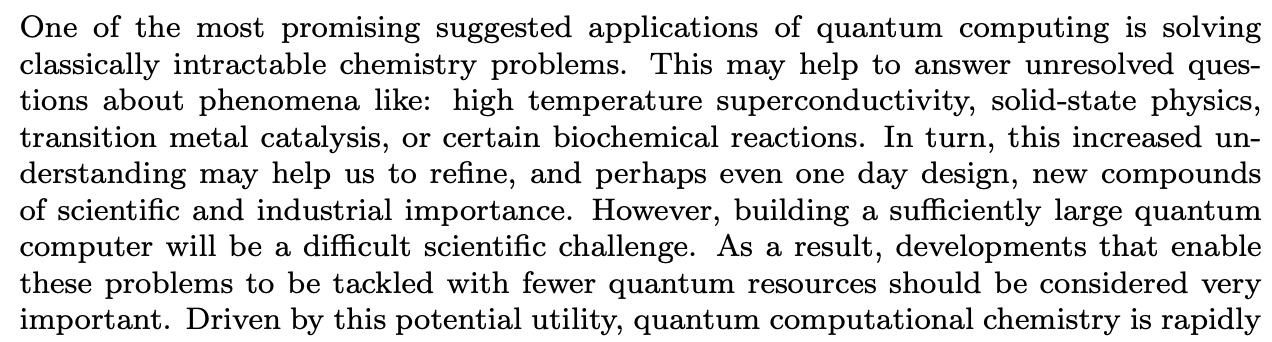
</p>

<p align="center">
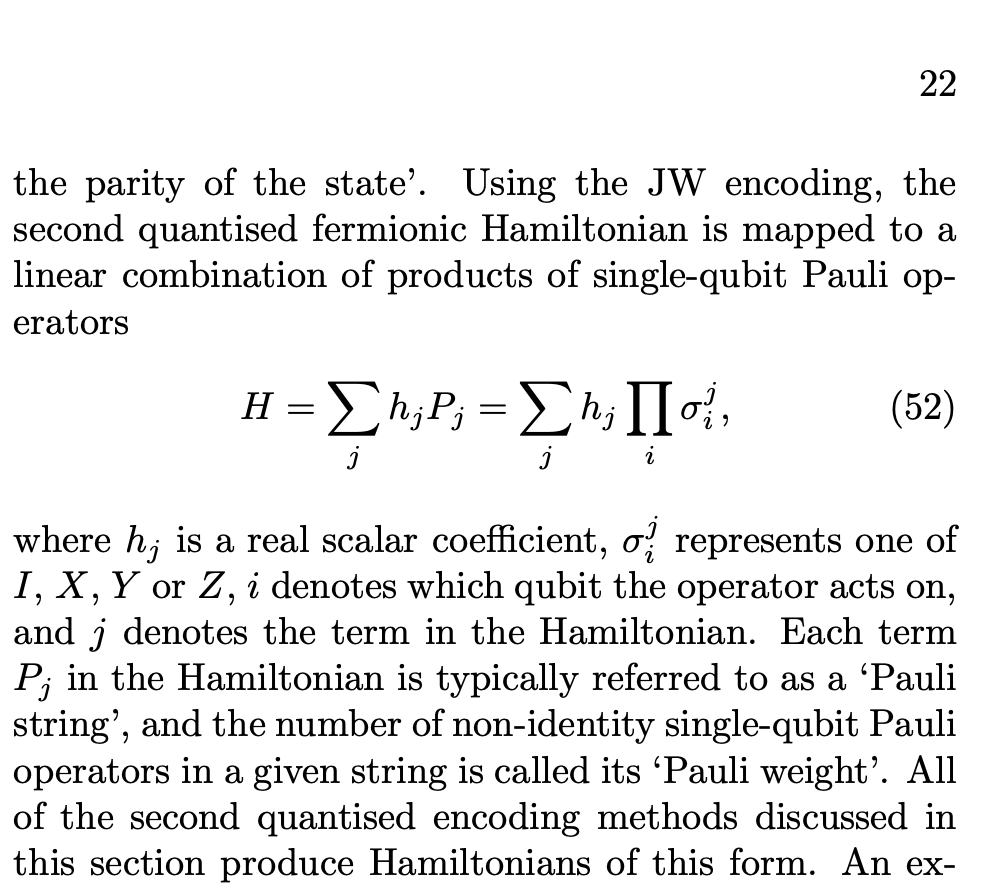
</p>


In [63]:
### you can play around here

np.random.seed(42)
dev = qml.device("default.qubit", wires=5) # exact simulation

# computational basis measurements: ZXXYY
#obsZZ = qml.PauliZ(0) @ qml.PauliX(1) @ qml.PauliX(2) @ qml.PauliY(3) @ qml.PauliY(4)
obs_big = (0.4*qml.PauliZ(0) @qml.PauliX(1) @ qml.PauliX(2) @ qml.PauliY(3) @ qml.PauliY(4) + 
0.6*qml.PauliZ(0)@qml.PauliZ(1) @ qml.PauliX(2) @ qml.PauliX(3) @ qml.PauliY(4) + 
1.2*qml.PauliZ(0)@qml.PauliX(1) @ qml.PauliX(2) @ qml.PauliY(3) @ qml.PauliY(4))

@qml.qnode(dev, interface="autograd")
def circuit_new(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1]) # control, target
    qml.RX(params[0], wires=0) # parameterized gate
    qml.RY(params[1], wires=1) # parameterized gate
    qml.RZ(params[2],wires = 1)
    qml.CNOT(wires = [2,4])
    qml.Hadamard(wires = 3)
    return qml.expval(obs_big)

# set the initial parameter values for the optimization
params = np.random.random([5], requires_grad=True)

In [64]:
# set the optimizer: vanilla gradient descent
opt = qml.AdamOptimizer(stepsize=0.4)

def cost_function(params):
  return circuit_new(params)

In [65]:
# set the number of steps

steps = 100

for i in range(steps):
  # update the circuit parameters
  params = opt.step(cost_function, params)

  if (i + 1) % 5 == 0: # every 5 steps
      print("Cost after step {:5d}: {: .7f}".format(i + 1, cost_function(params)))

print("Optimized rotation angles: {}".format(params))

Cost after step     5:  0.0000000
Cost after step    10:  0.0000000
Cost after step    15:  0.0000000
Cost after step    20:  0.0000000
Cost after step    25:  0.0000000
Cost after step    30:  0.0000000
Cost after step    35:  0.0000000
Cost after step    40:  0.0000000
Cost after step    45:  0.0000000
Cost after step    50:  0.0000000
Cost after step    55:  0.0000000
Cost after step    60:  0.0000000
Cost after step    65:  0.0000000
Cost after step    70:  0.0000000
Cost after step    75:  0.0000000
Cost after step    80:  0.0000000
Cost after step    85:  0.0000000
Cost after step    90:  0.0000000
Cost after step    95:  0.0000000
Cost after step   100:  0.0000000
Optimized rotation angles: [0.18343479 0.779691   0.59685016 0.44583275 0.09997492]


/tmp/ipykernel_5693/405523145.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


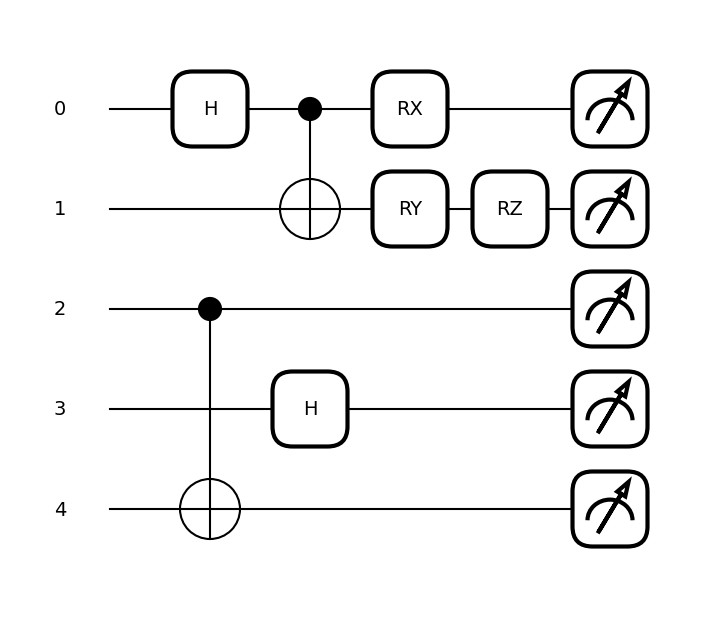

In [66]:
fig, ax = qml.draw_mpl(circuit_new)(params)
fig.show()


<div class="alert-block alert-success">
	&#10003; <b>Well done!</b> Lesson number 2 is over.
</div>